# Efficiency Plots


In [8]:
import os
import rootplotlib as rpl

import ROOT
from tqdm import tqdm
from copy import deepcopy     
from ROOT import TLegend ,TH1,TH2, TH1F, TFile
from ROOT import kBlack,kBlue,kRed,kAzure,kGreen,kMagenta,kCyan,kOrange,kGray,kYellow,kWhite,TColor,gStyle
from expand_folders import expand_folders
from prettytable import PrettyTable
from typing import List, Dict, Optional, Sequence, Any, Union


rpl.set_atlas_style()
rpl.suppress_root_warnings()
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2


Applying ATLAS style settings...
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
def GetHistogramRootPaths( path : str,
                           triggerList: List[str], 
                           remove_innef_before: bool = False, 
                           is_emulation: bool = False ,
                           basepath: str = "HLT/Egamma/Expert",
                           level_names = ['L1Calo', 'FastCalo', 'FastElectron', 'PrecisionCalo', 'PrecisionElectron'],
                           plot_names = ['et','eta','mu'],
                           levels_input = ['L1Calo','L1Calo','FastCalo','FastElectron','PrecisionCalo']
                          ):
        paths=[]; keys=[]

        def check_etthr_higher_than(trigger , etthr):
            et = int(trigger.replace('HLT_','').split('_')[0][1::])
            return True if et >= etthr else False

        entries=len(triggerList)
        step = int(entries/100) if int(entries/100) > 0 else 1
        for trigItem in tqdm(triggerList, desc='Making paths...', total=len(triggerList),  
                            bar_format='{desc:<5.5}{percentage:3.0f}%|{bar:10}{r_bar}'):
            ### Retrieve all paths
            for idx ,level in enumerate(level_names):
                for histname in plot_names:
                    if 'et' == histname and check_etthr_higher_than(trigItem,100):  histname='highet'
                    if is_emulation:
                        histpath = '{BASEPATH}/{TRIGGER}/Emulation/{LEVEL}/{HIST}'
                    else:
                        histpath = '{BASEPATH}/{TRIGGER}/Efficiency/{LEVEL}/{HIST}'
                    
                    paths.append(histpath.format(TRIGGER=trigItem,HIST='match_'+histname,LEVEL=level, BASEPATH=basepath))
                    if remove_innef_before:
                        paths.append(histpath.format(TRIGGER=trigItem,HIST= ('match_'+histname if idx!=0 else histname),LEVEL=levels_input[idx] ,BASEPATH=basepath))
                    else:
                        paths.append(histpath.format(TRIGGER=trigItem,HIST=histname,LEVEL='L1Calo', BASEPATH=basepath))
                    
                    if 'highet' == histname:  histname='et'
                    keys.append(trigItem+'_'+level+'_match_'+histname)
                    keys.append(trigItem+'_'+level+'_'+histname)
        
        # Loop over triggers
        return paths, keys


def GetHistogramFromMany( path: str, 
                          triggers: List[str], 
                          remove_innef_before: bool = False, 
                          is_emulation: bool = False,
                          basepath: str = "HLT/Egamma/Expert", 
                          prefix: str = 'Loading...',
                          level_names = ['L1Calo', 'FastCalo', 'FastElectron', 'PrecisionCalo', 'PrecisionElectron'],
                          plot_names = ['et','eta','mu'],
                          levels_input = ['L1Calo','L1Calo','FastCalo','FastElectron','PrecisionCalo']
                        ):
        
        paths , keys = GetHistogramRootPaths(path, 
                                             triggers, 
                                             remove_innef_before, 
                                             is_emulation, 
                                             basepath, 
                                             level_names, 
                                             plot_names, 
                                             levels_input
                                            )

        # internal retrive histogram
        def GetHistogram( f, path ,logger=None):
            try:            
                hist = f.Get(path)
                hist.GetEntries()
                return hist
            except:
                return None
        # internal integration
        def SumHists(histList):
            totalHist = None
            for hist in histList:
                if hist is None:
                    continue
                if totalHist is None:
                    totalHist=deepcopy(hist.Clone())
                else:
                    totalHist.Add( hist )
            return totalHist

        files = expand_folders(path)
        hists = {}
        for f in tqdm(files, desc='Loading', bar_format='{desc:<5.5}{percentage:3.0f}%|{bar:10}{r_bar}'):
            _f = TFile(f, 'read')
            for idx, _path in enumerate(paths):
                    hist = GetHistogram(_f, _path)
                    if (hist is not None):
                        if not keys[idx] in hists.keys():
                            hists[keys[idx]]=[deepcopy(hist.Clone())]
                        else:
                            hists[keys[idx]].append(deepcopy(hist.Clone()))
            _f.Close

        for key in hists.keys():
            hists[key]=SumHists(hists[key])
        return hists


def GetXAxisWorkAround( hist, nbins, xmin, xmax ):
  from ROOT import TH1F
  h=TH1F(hist.GetName()+'_resize', hist.GetTitle(), nbins,xmin,xmax)
  for bin in range(h.GetNbinsX()):
    x = h.GetBinCenter(bin+1)
    m_bin = hist.FindBin(x)
    y = hist.GetBinContent(m_bin)
    error = hist.GetBinError(m_bin)
    h.SetBinContent(bin+1,y)
    h.SetBinError(bin+1,error)
  return h


def make_table( data : Dict[str, TH1F], 
                trigger : str, 
                levels : List[str] = ['L1Calo','FastCalo','FastElectron','PrecisionCalo','PrecisionElectron'] 
                ):
    
    t = PrettyTable(['Level','Accept'])
    for lev in levels:
        passed = data[trigger+'_'+lev+'_match_eta'].GetEntries()
        total = data[trigger+'_'+lev+'_eta'].GetEntries()
        eff = passed/total*100
        tex = '%1.2f (%d/%d)'%(eff,passed,total)
        t.add_row([lev, tex])
    print(t)

## 1) Read all files:

### 1.1) Create keys and paths

In [10]:
triggers = [
            'HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI',
            ]
path = 'task/datasets/task.output.root'
h_data = GetHistogramFromMany(path, triggers, remove_innef_before=False, is_emulation=False, basepath="trigger")

Loadi100%|██████████| 496/496 [00:01<00:00, 295.32it/s]


In [11]:
h_data

{'HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_L1Calo_match_et': <cppyy.gbl.TH1F object at 0x55b79d0b41a0>,
 'HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_L1Calo_et': <cppyy.gbl.TH1F object at 0x55b79d067910>,
 'HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_L1Calo_match_eta': <cppyy.gbl.TH1F object at 0x55b79d054c10>,
 'HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_L1Calo_eta': <cppyy.gbl.TH1F object at 0x55b79d07a9b0>,
 'HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_L1Calo_match_mu': <cppyy.gbl.TH1F object at 0x55b79d0b1100>,
 'HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_L1Calo_mu': <cppyy.gbl.TH1F object at 0x55b79d0aace0>,
 'HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_FastCalo_match_et': <cppyy.gbl.TH1F object at 0x55b79d073610>,
 'HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_FastCalo_et': <cppyy.gbl.TH1F object at 0x55b79d0995f0>,
 'HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_FastCalo_match_eta': <cppyy.gbl.TH1F object at 0x55b79d0b0660>,
 'HLT_e

In [12]:
def add_legend( x, y, legends, textsize=14, pad=None):
    rpl.add_legend( legends,x,y,x+0.98,y+0.20,textsize=textsize, option='p', pad=pad)

def set_marker_size( fig, marker_size , pad=None):
    canvas = fig.get_pad(pad)
    for primitive in canvas.GetListOfPrimitives():
        if issubclass(type(primitive), TH1) or issubclass(type(primitive),TH2):
            primitive.SetMarkerSize(marker_size)

In [13]:
os.makedirs('output', exist_ok=True)

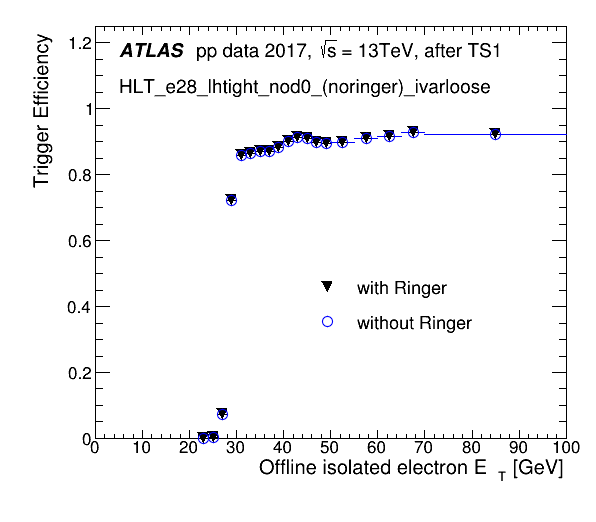

In [14]:
colors = [kBlack,kBlue]
markers = [23, 24]

hists = [
            rpl.hist1d.divide( h_data['HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_PrecisionElectron_match_et'],
                               h_data['HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_PrecisionElectron_et']),
            rpl.hist1d.divide( h_data['HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_PrecisionElectron_match_et'],
                               h_data['HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_PrecisionElectron_et']),
        ]
[h.SetMarkerSize(200) for h in hists]
fig = rpl.plot_profiles( hists, 'Offline isolated electron E_{T} [GeV]', 'Trigger Efficiency',  
                         colors, markers, name='',title='',canw=600, canh=550 )
#rpl.set_atlas_label(0.2,0.88,'Internal, pp data 2017 #sqrt{s}= 13TeV', textsize=0.06

set_marker_size(fig, 1.4)
rpl.add_text( 0.2, 0.89, 'ATLAS'   , textsize=0.04, textfont=72)
rpl.add_text( 0.33, 0.89, 'pp data 2017, #sqrt{s} = 13TeV, after TS1', textsize=0.04)
rpl.add_text( 0.2, 0.82, 'HLT_e28_lhtight_nod0_(noringer)_ivarloose', textsize=0.04)
add_legend( 0.5,0.35,['with Ringer', 'without Ringer'] , 20)
rpl.set_yaxis_ranges(0, 1.25) #, pad='pad_top')

fig.show()
fig.savefig('output/eff_EGAM1_e28_ringer_and_noringer_2017_after_ts1_HLT_et.pdf')

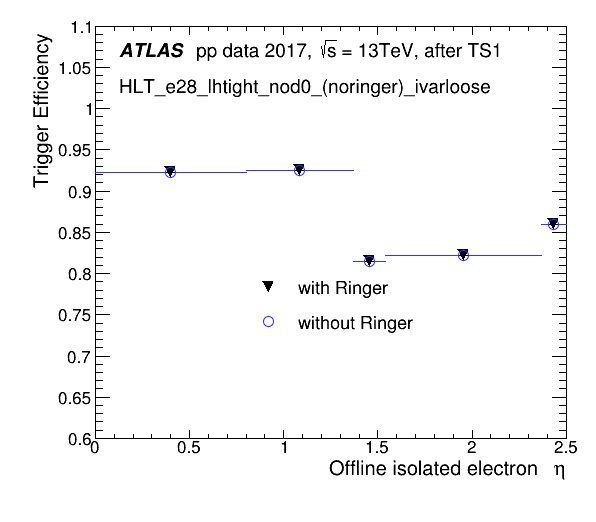

In [15]:
colors = [kBlack,kBlue-4]
markers = [23, 24]

hists = [
            rpl.hist1d.divide( h_data['HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_PrecisionElectron_match_eta'],
                               h_data['HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_PrecisionElectron_eta']),
            rpl.hist1d.divide( h_data['HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_PrecisionElectron_match_eta'],
                               h_data['HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_PrecisionElectron_eta']),
        ]
fig = rpl.plot_profiles( hists, 'Offline isolated electron #eta', 'Trigger Efficiency',  
                         colors, markers, name='',title='',canw=600, canh=550 )
set_marker_size(fig, 1.4)

rpl.add_text( 0.2, 0.89, 'ATLAS'   , textsize=0.04, textfont=72)
rpl.add_text( 0.33, 0.89, 'pp data 2017, #sqrt{s} = 13TeV, after TS1', textsize=0.04)
rpl.add_text( 0.2, 0.82, 'HLT_e28_lhtight_nod0_(noringer)_ivarloose', textsize=0.04)
add_legend( 0.4,0.35,['with Ringer', 'without Ringer'] , 20)
rpl.set_yaxis_ranges(0.6, 1.1)

fig.show()
fig.savefig('output/eff_EGAM1_e28_ringer_and_noringer_2017_after_ts1_HLT_eta.pdf')

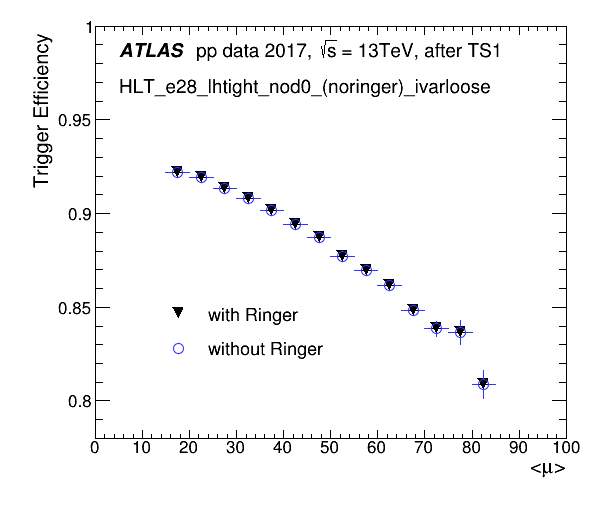

In [16]:
colors = [kBlack,kBlue-4]
markers = [23, 24]

hists = [
            rpl.hist1d.divide( h_data['HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_PrecisionElectron_match_mu'],
                               h_data['HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_PrecisionElectron_mu']),
            rpl.hist1d.divide( h_data['HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_PrecisionElectron_match_mu'],
                               h_data['HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI_PrecisionElectron_mu']),
        ]
#hists = [ rpl.hist1d.rebin( h , 10, 20, 70 ) for h in hists ]

#hists = [ rpl.hist1d.divide( hists[0], hists[1] ), rpl.hist1d.divide(hists[2], hists[3]) ]

#fig = rpl.create_canvas('my_canvas')
fig = rpl.plot_profiles( hists, '<#mu>', 'Trigger Efficiency',  colors, markers,
                         name='',title='',canw=600, canh=550 )
set_marker_size(fig, 1.4)

rpl.add_text( 0.2, 0.89, 'ATLAS'   , textsize=0.04, textfont=72)
rpl.add_text( 0.33, 0.89, 'pp data 2017, #sqrt{s} = 13TeV, after TS1', textsize=0.04)
rpl.add_text( 0.2, 0.82, 'HLT_e28_lhtight_nod0_(noringer)_ivarloose', textsize=0.04)
add_legend( 0.25,0.3,['with Ringer', 'without Ringer'] , 20)
rpl.set_yaxis_ranges(0.78, 1)

fig.show()
fig.savefig('output/eff_EGAM1_e28_ringer_and_noringer_2017_after_ts1_HLT_mu.pdf')

In [17]:
make_table(h_data, 'HLT_e28_lhtight_nod0_noringer_ivarloose_eEM24VHI')


+-------------------+--------------------------+
|       Level       |          Accept          |
+-------------------+--------------------------+
|       L1Calo      | 100.00 (1523441/1523441) |
|      FastCalo     | 99.42 (1514564/1523441)  |
|    FastElectron   | 99.42 (1514564/1523441)  |
|   PrecisionCalo   | 99.21 (1511374/1523441)  |
| PrecisionElectron | 89.07 (1356853/1523441)  |
+-------------------+--------------------------+
